# LLM score comparison

In [6]:
import pandas as pd

In [7]:
scores_llama = pd.read_csv("data/EuroParl/scored_llama/scored_data_0_500.csv", sep=';', encoding="utf-8-sig")
scores_gpt = pd.read_csv("data/EuroParl/scored_gpt/scored_data_gpt_first1000.csv", sep=';', encoding="utf-8-sig")
scores_gpt = scores_gpt.iloc[:500]
scores_llama['score_diff'] = scores_llama['score'] - scores_gpt['score'].values
scores_llama.sort_values(by=['score_diff']).to_csv(
                f"data/EuroParl/scored_diff.csv",
                sep=";",
                index=False,
                encoding="utf-8-sig"
            )

In [8]:
import numpy as np

mse = np.median(
    (scores_llama["score"].values - scores_gpt["score"].values)
)

print("Mean Squared Difference:", mse)

Mean Squared Difference: -0.09999999999999998


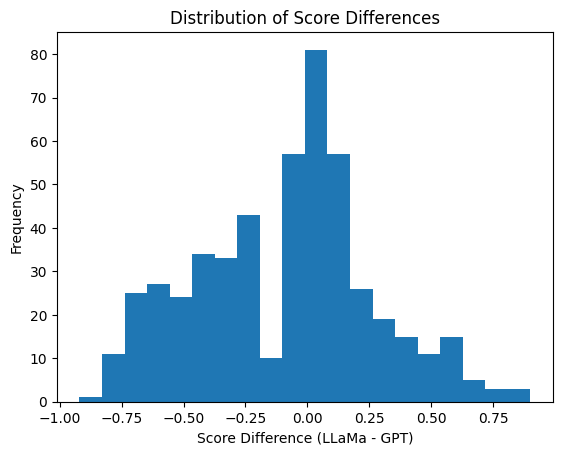

In [9]:
diff = scores_llama["score"] - scores_gpt["score"]
import matplotlib.pyplot as plt

plt.hist(diff, bins=20)
plt.xlabel("Score Difference (LLaMa - GPT)")
plt.ylabel("Frequency")
plt.title("Distribution of Score Differences")
plt.show()